# 1D-CNN-ResBiGRU for Smartwatch Gesture Recognition

Model from Mekruksavanich, Phaphan & Jitpattanakul (2025), *Lobachevskii J. Math.*
**46**(1), 464-480 — adapted to **your** smartwatch IMU data
(`ax, ay, az, gx, gy, gz`) and **your** gesture set.

The paper's two datasets (**UWave**, **GesHome**) are just public benchmarks they
tested on; they are NOT your data. This notebook is set up for your own recordings.

---
### How unspecified values are marked
The paper doesn't report several hyperparameters. Choices I made (not from the paper)
are marked `# >>> NOT IN PAPER - TUNE`; paper-specified values are marked `# PAPER:`.
Things specific to YOUR data are marked `# >>> YOUR DATA`.

Out of the box this runs on **synthetic data shaped exactly like yours** (6 channels,
10 gesture classes) so you can see the whole pipeline work. Flip `DATASET` to
`"smartwatch"` and point `SMARTWATCH_ROOT` at your CSV folder for the real run.

### Changelog - what was adapted from the paper's generic version

- **Labels from folder names**: reads the gesture code from the parent folder
  (`CCW_no_tremor/` -> `CCW`). The separate U/D/N wrist-orientation session is
  auto-skipped (its codes aren't in `GESTURE_CLASSES`).
- **Irregular sampling handled**: your watch samples unevenly (5-55 ms gaps), so each
  recording is interpolated onto a uniform `target_len` grid using its `t_ms` column.
- **Per-channel normalization**: accel and gyro live on different scales, so min-max is
  applied per channel (not globally).
- **Data audit cell (Section 5)**: lists every folder with files-found vs loaded, plus
  per-class totals - so you can confirm all your data is used.
- **`QUICK_TEST` flag (default `False`)**: full 200-epoch training is now the default.
  Removed the buried `max_epochs = 8` smoke-test overrides that caused under-training
  (the symptom: several classes stuck at 0.00 recall).
- **Overfitting check (Section 9)**: reports train-vs-test accuracy gap, per-fold spread,
  and train/validation learning curves, with a plain-language verdict.
- **Train/test sizes printed**: both the CV cell and the per-gesture cell now print how
  many samples per class go into train vs test.
- **Class weighting (`use_class_weights`, default `True`)**: uses ALL your CSVs even when
  some gestures have many more than others, and up-weights the rarer classes in the loss so
  they aren't ignored. No data is discarded.
- **`lr_decay_mode` toggle**: `"paper"` (Table 1 decay, faithful) or `"constant"` (try
  this if the model still underfits on the small single-person dataset).
- **Bug fix**: moved `os`/`glob` imports to the top so `label_from_path` works.


## 1. Setup

In [1]:
# !pip install tensorflow scipy scikit-learn matplotlib pandas numpy
import os, glob   # CHANGED: moved to top level so label_from_path() can use os/glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from scipy.signal import butter, filtfilt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight   # CHANGED: for imbalance handling
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow", tf.__version__)

I0000 00:00:1782746498.287299  303326 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782746498.845696  303326 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782746502.309020  303326 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


## 2. Your gestures + configuration

`GESTURE_CLASSES` are your 10 gesture codes (the class labels). The model predicts one
of these per recording. The `tremor` column in your CSVs is a separate per-row
annotation and is **ignored** for gesture recognition — if you ever want to predict
tremor instead, that's a different label and a binary task.

In [ ]:
# ---- YOUR gesture vocabulary (label = gesture code) --------------------------
GESTURE_CLASSES = ["Uw", "Ue", "Dn", "Ds", "Dw", "De", "DUD", "Un"]
GESTURE_NAMES = {                       # just for readable reports
    "Uw": "Quadrant Left", "Ue": "Quadrant Right",
    "Dn": "Letter Up",     "Ds": "Letter Down",
    "Dw": "Letter Left",   "De": "Letter Right",
    "DUD": "Select",       "Un": "Space"
}
SENSOR_COLS = ["ax", "ay", "az", "gx", "gy", "gz"]   # >>> YOUR DATA: 6 IMU channels

# ---- pick your dataset ----
DATASET = "synthetic"            # "synthetic" | "smartwatch"
SMARTWATCH_ROOT = "../src/gesture_data/gesture_data_june24_sofie_rightarm_sitting"   # >>> YOUR DATA

DATASET_INFO = {
    "smartwatch": {"fs": 200, "n_channels": 6, "n_classes": len(GESTURE_CLASSES)},
    "synthetic":  {"fs": 200, "n_channels": 6, "n_classes": len(GESTURE_CLASSES)},
}
info = DATASET_INFO[DATASET]

CONFIG = {
    # ---------- PREPROCESSING ----------
    # Your watch samples irregularly (5-55 ms gaps), so each recording is interpolated
    # onto a uniform grid of TARGET_LEN steps using its t_ms column. One recording =
    # one training sample (each file is a single gesture with lead-in/out).
    "target_len":    128,                 # >>> NOT IN PAPER / YOUR DATA - uniform length per gesture, TUNE
    # PAPER says low-pass filter for noise removal, but NOT the cutoff/order:
    "lp_cutoff_hz":  20.0,                # >>> NOT IN PAPER - TUNE (Hz; gesture energy is low-freq)
    "lp_order":      4,                   # >>> NOT IN PAPER - TUNE
    # PAPER: min-max to [-1, 1]. Per-channel matters here (accel vs gyro scales differ):
    "minmax_per_channel": True,          # >>> keep True for your data

    # ---------- CONVOLUTION BLOCKS ----------
    "n_conv_blocks": 3,                   # PAPER: "Convolution Block x3" (Fig. 4)
    "conv_filters":  64,                  # >>> NOT IN PAPER - TUNE
    "kernel_size":   3,                   # >>> NOT IN PAPER - TUNE
    "conv_strides":  1,                   # >>> NOT IN PAPER - TUNE
    "pool_size":     2,                   # >>> NOT IN PAPER - TUNE
    "dropout_rate":  0.3,                 # >>> NOT IN PAPER - TUNE

    # ---------- RESIDUAL BiGRU BLOCKS ----------
    "n_bigru_blocks": 2,                  # >>> NOT IN PAPER - Fig. 4 ambiguous - TUNE
    "gru_units":      64,                 # >>> NOT IN PAPER - TUNE

    # ---------- CLASSIFIER HEAD ----------
    "dense_units":   64,                  # >>> NOT IN PAPER - TUNE (0 = straight to softmax)
    "reduction":     "gap",              # >>> NOT IN PAPER - "gap" | "flatten" | "last"

    # ---------- OPTIMIZER (Table 1, all PAPER) ----------
    "lr": 0.001, "beta_1": 0.9, "beta_2": 0.999, "epsilon": 1e-8, "decay": 0.01,  # PAPER

    # ---------- REGULARIZATION / TRAINING ----------
    "l2_lambda":  1e-4,                   # >>> NOT IN PAPER - TUNE
    "lr_decay_mode": "paper",            # CHANGED: new toggle. "paper" (Table 1 decay) | "constant" if model underfits
    "use_class_weights": True,           # CHANGED: True = weight loss by inverse class frequency (uses ALL data, fixes imbalance)
    "n_folds":    5,                      # PAPER: 5-fold CV
    "max_epochs": 200,                    # PAPER: up to 200 epochs
    "batch_size": 32,                     # >>> NOT IN PAPER - TUNE (small until you have lots of data)
    "es_patience": 20,                    # >>> NOT IN PAPER - TUNE
    "es_monitor": "val_loss",            # >>> NOT IN PAPER - TUNE
}
QUICK_TEST = False     # CHANGED: new flag. False = full 200-epoch training (default). True = fast 8-epoch smoke run.
N_CLASSES  = info["n_classes"]
N_CHANNELS = info["n_channels"]
print(f"Dataset={DATASET} | target_len={CONFIG['target_len']} | "
      f"channels={N_CHANNELS} | classes={N_CLASSES} ({GESTURE_CLASSES})")

Dataset=synthetic | target_len=128 | channels=6 | classes=10 (['Uw', 'Ue', 'Dn', 'Ds', 'Dw', 'De', 'DUD', 'Un', 'CCW', 'CW'])


## 3. Data loading

In [3]:
def load_synthetic(n_per_class=40, T=None, C=None, K=None, seed=SEED):
    """Class-conditional signals shaped like your data so the pipeline beats chance.
    Returns X (n, T, C) in [-1, 1] and y (n,)."""
    T = T or CONFIG["target_len"]; C = C or N_CHANNELS; K = K or N_CLASSES
    rng = np.random.default_rng(seed)
    n = n_per_class * K
    X = np.zeros((n, T, C), dtype="float32")
    y = np.repeat(np.arange(K), n_per_class)
    t = np.linspace(0, 2 * np.pi, T)
    for i in range(n):
        for c in range(C):
            X[i, :, c] = np.sin((y[i] + 1) * t + c) + 0.3 * rng.standard_normal(T)
    return X, y

In [4]:
# CHANGED: gesture label is taken from the FOLDER name (matches your layout)
def label_from_path(fp):
    """Your layout:  <session>/<CODE>_no_tremor/<CODE>_no_tremor_<n>.csv
    The gesture code is the start of the PARENT FOLDER name, e.g.
    '.../CCW_no_tremor/CCW_no_tremor_7.csv' -> 'CCW'.
    Recursive globbing means you can point root at one session folder OR at the
    parent containing several sessions of the SAME label set."""
    folder = os.path.basename(os.path.dirname(fp))   # e.g. 'CCW_no_tremor'
    return folder.split("_")[0]                       # e.g. 'CCW'   >>> EDIT if your rule differs

def load_smartwatch(root):
    """Read your CSVs. Each file = one gesture instance.
    Returns list of (t_ms, sig[T,6], label_index). Filtering / resampling / scaling
    happen in build_dataset(). Folders whose code is not in GESTURE_CLASSES
    (e.g. the U/D/N wrist-orientation session) are skipped automatically."""
    samples, skipped = [], {}
    for fp in sorted(glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)):
        code = label_from_path(fp)
        if code not in GESTURE_CLASSES:
            skipped[code] = skipped.get(code, 0) + 1; continue
        df = pd.read_csv(fp)
        if not set(SENSOR_COLS).issubset(df.columns):
            skipped["bad_columns"] = skipped.get("bad_columns", 0) + 1; continue
        sig = df[SENSOR_COLS].values.astype("float32")
        if len(sig) < 4:
            continue
        samples.append((df["t_ms"].values.astype("float64"), sig, GESTURE_CLASSES.index(code)))
    if skipped:
        print("skipped:", skipped)   # e.g. {'D': 100, 'N': 100, 'U': 100} = orientation session
    if not samples:
        raise FileNotFoundError(
            f"No labeled CSVs under {root}. Expected '<CODE>_no_tremor/<files>.csv' "
            f"with CODE in {GESTURE_CLASSES}.")
    print(f"Loaded {len(samples)} recordings from {root}")
    return samples

## 4. Preprocessing
Low-pass filter (on the real per-file rate) -> resample irregular timestamps onto a
uniform grid of `target_len` steps -> per-channel min-max to [-1, 1].

In [5]:
def estimate_fs(t_ms):
    dt = np.median(np.diff(t_ms))
    return 1000.0 / dt if dt > 0 else 100.0

def lowpass_filter(x, fs, cutoff, order):
    if len(x) <= 3 * (order + 1):     # too short for filtfilt -> skip safely
        return x
    nyq = 0.5 * fs
    b, a = butter(order, min(cutoff / nyq, 0.99), btype="low")
    return filtfilt(b, a, x, axis=0)

def resample_uniform(t_ms, sig, out_len):
    """Linear-interpolate each channel onto a uniform time grid (fixes irregular sampling
    and makes every recording the same length)."""
    grid = np.linspace(t_ms[0], t_ms[-1], out_len)
    out = np.empty((out_len, sig.shape[1]), dtype="float32")
    for c in range(sig.shape[1]):
        out[:, c] = np.interp(grid, t_ms, sig[:, c])
    return out

def minmax_scale(x, per_channel=True, feat_range=(-1.0, 1.0)):
    lo, hi = feat_range
    axis = 0 if per_channel else None
    mn = x.min(axis=axis, keepdims=True); mx = x.max(axis=axis, keepdims=True)
    rng = np.where((mx - mn) == 0, 1.0, (mx - mn))
    return ((x - mn) / rng * (hi - lo) + lo).astype("float32")

def build_dataset():
    if DATASET == "synthetic":
        X, y = load_synthetic()
        X = np.stack([minmax_scale(s, CONFIG["minmax_per_channel"]) for s in X])
        return X.astype("float32"), y
    # ---- smartwatch ----
    raw = load_smartwatch(SMARTWATCH_ROOT)
    Xs, ys = [], []
    for t, sig, label in raw:
        fs = estimate_fs(t)
        sig = lowpass_filter(sig, fs, CONFIG["lp_cutoff_hz"], CONFIG["lp_order"])
        sig = resample_uniform(t, sig, CONFIG["target_len"])
        sig = minmax_scale(sig, CONFIG["minmax_per_channel"])
        Xs.append(sig); ys.append(label)
    return np.asarray(Xs, dtype="float32"), np.asarray(ys)

X, y = build_dataset()
print("X", X.shape, "| y", y.shape, "| class counts", np.bincount(y, minlength=N_CLASSES))

X (400, 128, 6) | y (400,) | class counts [40 40 40 40 40 40 40 40 40 40]


## 5. Data audit - what actually got loaded
This answers "is it using all my data?" - it lists every folder, how many CSVs are in it, and how many were actually loaded (and why any were dropped).

In [6]:
def audit_folders(root):   # CHANGED: new - reports files-found vs loaded per folder
    from collections import Counter
    folders = sorted({os.path.dirname(fp)
                      for fp in glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)})
    by_code = Counter(); rows = []
    for folder in folders:
        files = sorted(glob.glob(os.path.join(folder, "*.csv")))
        code = label_from_path(os.path.join(folder, "x.csv"))
        loaded = short = bad = 0
        for fp in files:
            try:
                df = pd.read_csv(fp)
            except Exception:
                bad += 1; continue
            if not set(SENSOR_COLS).issubset(df.columns): bad += 1
            elif len(df) < 4: short += 1
            else: loaded += 1
        used = code in GESTURE_CLASSES
        if used: by_code[code] += loaded
        rows.append((os.path.basename(folder), code, used, len(files), loaded, short, bad))
    print(f"{'folder':40}{'code':6}{'used':6}{'files':7}{'loaded':8}{'short':7}{'badcol':7}")
    print("-" * 83)
    for name, code, used, nf, ld, sh, bd in rows:
        print(f"{name[:39]:40}{code:6}{('yes' if used else 'NO'):6}{nf:<7}{ld:<8}{sh:<7}{bd:<7}")
    print("-" * 83)
    print("Usable samples per gesture class:")
    for c in GESTURE_CLASSES:
        flag = "" if by_code.get(c, 0) else "   <-- ZERO (check folder name / columns)"
        print(f"  {c:5} {by_code.get(c, 0):4d}{flag}")
    print(f"\nTOTAL usable gesture samples: {sum(by_code.values())}")
    missing = [c for c in GESTURE_CLASSES if by_code.get(c, 0) == 0]
    if missing: print("MISSING classes:", missing)
    return rows

if DATASET == "smartwatch":
    _ = audit_folders(SMARTWATCH_ROOT)
else:
    from collections import Counter
    print("Synthetic data | class counts:", dict(Counter(y.tolist())))
print(f"\nFinal arrays into the model:  X={X.shape}  y={y.shape}")

Synthetic data | class counts: {0: 40, 1: 40, 2: 40, 3: 40, 4: 40, 5: 40, 6: 40, 7: 40, 8: 40, 9: 40}

Final arrays into the model:  X=(400, 128, 6)  y=(400,)


## 6. Model

**Convolution block** (Fig. 4): `Conv1D -> BatchNorm -> ReLU -> MaxPool -> Dropout` x3.

**Residual BiGRU block** (eq. in section 3.3.2): each direction gets its own
residual + layer-norm, then the two are concatenated:
$$x^{f}_{i+1}=\mathrm{LN}(x^{f}_i+\mathrm{GRU}(x^{f}_i)),\;
x^{b}_{i+1}=\mathrm{LN}(x^{b}_i+\mathrm{GRU}(x^{b}_i)),\;
y=\mathrm{concat}(x^f,x^b)$$

In [7]:
def conv_block(x, cfg):
    x = layers.Conv1D(cfg["conv_filters"], cfg["kernel_size"],
                      strides=cfg["conv_strides"], padding="same",
                      kernel_regularizer=regularizers.l2(cfg["l2_lambda"]))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)          # >>> NOT IN PAPER: activation unnamed; ReLU standard
    x = layers.MaxPooling1D(pool_size=cfg["pool_size"], padding="same")(x)
    x = layers.Dropout(cfg["dropout_rate"])(x)
    return x

def residual_bigru_block(x, cfg):
    units = cfg["gru_units"]; l2 = regularizers.l2(cfg["l2_lambda"])
    f = layers.GRU(units, return_sequences=True, kernel_regularizer=l2)(x)
    b = layers.GRU(units, return_sequences=True, go_backwards=True, kernel_regularizer=l2)(x)
    b = layers.Lambda(lambda t: tf.reverse(t, axis=[1]))(b)   # restore forward time order
    shortcut = x if x.shape[-1] == units else layers.Dense(units)(x)  # projection if dims differ
    f = layers.LayerNormalization()(layers.Add()([f, shortcut]))
    b = layers.LayerNormalization()(layers.Add()([b, shortcut]))
    return layers.Concatenate()([f, b])

def reduce_sequence(x, how):
    if how == "gap":     return layers.GlobalAveragePooling1D()(x)
    if how == "flatten": return layers.Flatten()(x)
    if how == "last":    return layers.Lambda(lambda t: t[:, -1, :])(x)
    raise ValueError(how)

def build_model(input_shape, n_classes, cfg):
    inp = layers.Input(shape=input_shape); x = inp
    for _ in range(cfg["n_conv_blocks"]):  x = conv_block(x, cfg)
    for _ in range(cfg["n_bigru_blocks"]): x = residual_bigru_block(x, cfg)
    x = reduce_sequence(x, cfg["reduction"])
    if cfg["dense_units"] > 0:
        x = layers.Dense(cfg["dense_units"], activation="relu",
                         kernel_regularizer=regularizers.l2(cfg["l2_lambda"]))(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return models.Model(inp, out)

def make_optimizer(cfg):
    # Table 1 includes decay=0.01 (learning-RATE decay). It decays fast on small datasets,
    # which can stall learning -> set lr_decay_mode="constant" if the model underfits.
    use_decay = cfg.get("lr_decay_mode", "paper") == "paper"   # CHANGED: decay is now switchable
    try:
        return tf.keras.optimizers.legacy.Adam(
            learning_rate=cfg["lr"], beta_1=cfg["beta_1"], beta_2=cfg["beta_2"],
            epsilon=cfg["epsilon"], decay=(cfg["decay"] if use_decay else 0.0))
    except (AttributeError, TypeError, ImportError):
        lr = tf.keras.optimizers.schedules.InverseTimeDecay(cfg["lr"], 1, cfg["decay"]) if use_decay else cfg["lr"]
        return tf.keras.optimizers.Adam(learning_rate=lr, beta_1=cfg["beta_1"],
                                        beta_2=cfg["beta_2"], epsilon=cfg["epsilon"])

def class_weights(y_tr, n_classes, cfg):
    # CHANGED: keeps ALL samples but up-weights rarer gestures so big classes don't dominate.
    if not cfg.get("use_class_weights", True):
        return None
    present = np.unique(y_tr)
    w = compute_class_weight("balanced", classes=present, y=y_tr)
    d = {c: 1.0 for c in range(n_classes)}
    d.update({int(c): float(wi) for c, wi in zip(present, w)})
    return d

build_model(X.shape[1:], N_CLASSES, CONFIG).summary()

W0000 00:00:1782746505.744324  303617 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782746506.099696  303326 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 64)   │      1,216 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 64)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 64, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 32, 64)    │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 64)    │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 32, 64)    │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 16, 64)    │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 64)    │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 16, 64)    │     24,960 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 16, 64)    │     24,960 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 16, 64)    │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 64)    │          0 │ gru[0][0],      

 Total params: 168,778 (659.29 KB)

 Trainable params: 168,394 (657.79 KB)

 Non-trainable params: 384 (1.50 KB)

## 7. Training - 5-fold cross-validation

PAPER: 5-fold CV, cross-entropy + L2, Adam (Table 1), <=200 epochs, early stopping.

In [8]:
def run_cv(X, y, cfg, n_classes, verbose=0):
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True, random_state=SEED)
    # CHANGED: also track TRAIN metrics + history so we can measure overfitting (train vs test gap)
    results = {"acc": [], "loss": [], "f1": [], "train_acc": [], "train_loss": [], "history": []}
    for fold, (tr, te) in enumerate(skf.split(X, y), 1):
        tf.keras.backend.clear_session()
        Ytr = tf.keras.utils.to_categorical(y[tr], n_classes)
        Yte = tf.keras.utils.to_categorical(y[te], n_classes)
        model = build_model(X.shape[1:], n_classes, cfg)
        model.compile(optimizer=make_optimizer(cfg),
                      loss="categorical_crossentropy", metrics=["accuracy"])
        es = EarlyStopping(monitor=cfg["es_monitor"], patience=cfg["es_patience"],
                           restore_best_weights=True)
        h = model.fit(X[tr], Ytr, validation_data=(X[te], Yte),
                      epochs=cfg["max_epochs"], batch_size=cfg["batch_size"],
                      class_weight=class_weights(y[tr], n_classes, cfg),   # CHANGED: imbalance handling
                      callbacks=[es], verbose=verbose)
        tr_loss, tr_acc = model.evaluate(X[tr], Ytr, verbose=0)   # CHANGED: train-set score
        loss, acc = model.evaluate(X[te], Yte, verbose=0)
        pred = model.predict(X[te], verbose=0).argmax(1)
        results["acc"].append(acc); results["loss"].append(loss)
        results["train_acc"].append(tr_acc); results["train_loss"].append(tr_loss)
        results["f1"].append(f1_score(y[te], pred, average="macro"))
        results["history"].append(h.history)
        print(f"Fold {fold}: train_acc={tr_acc:.4f}  test_acc={acc:.4f}  "
              f"gap={tr_acc-acc:+.4f}  test_f1={results['f1'][-1]:.4f}")
    return results

# CHANGED: full training by default (was a hard-coded 8-epoch override here)
run_cfg = dict(CONFIG)
run_cfg["max_epochs"] = 8 if QUICK_TEST else CONFIG["max_epochs"]
print(f"Training {run_cfg['max_epochs']} epochs/fold | {CONFIG['n_folds']} folds | "
      f"{len(X)} total samples (~{len(X)*(CONFIG['n_folds']-1)//CONFIG['n_folds']} train / "
      f"~{len(X)//CONFIG['n_folds']} test per fold)")
results = run_cv(X, y, run_cfg, N_CLASSES, verbose=0)

Training 200 epochs/fold | 5 folds | 400 total samples (~320 train / ~80 test per fold)
Fold 1: train_acc=1.0000  test_acc=1.0000  gap=+0.0000  test_f1=1.0000
Fold 2: train_acc=1.0000  test_acc=1.0000  gap=+0.0000  test_f1=1.0000
Fold 3: train_acc=1.0000  test_acc=1.0000  gap=+0.0000  test_f1=1.0000
Fold 4: train_acc=1.0000  test_acc=1.0000  gap=+0.0000  test_f1=1.0000
Fold 5: train_acc=1.0000  test_acc=1.0000  gap=+0.0000  test_f1=1.0000


## 8. Results

  acc: 1.0000 (+/- 0.0000)
 loss: 0.0657 (+/- 0.0004)
   f1: 1.0000 (+/- 0.0000)


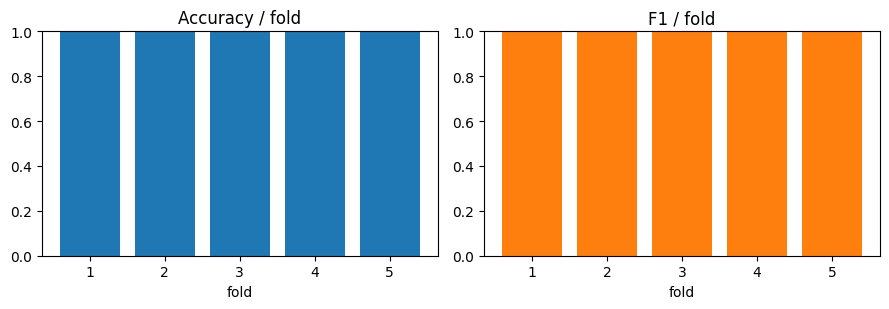

In [9]:
def summarize(res):
    for k in ("acc", "loss", "f1"):
        arr = np.array(res[k]); print(f"{k:>5}: {arr.mean():.4f} (+/- {arr.std():.4f})")
summarize(results)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].bar(range(1, len(results["acc"]) + 1), results["acc"]); ax[0].set_title("Accuracy / fold"); ax[0].set_ylim(0, 1)
ax[1].bar(range(1, len(results["f1"]) + 1), results["f1"], color="tab:orange"); ax[1].set_title("F1 / fold"); ax[1].set_ylim(0, 1)
for a in ax: a.set_xlabel("fold")
plt.tight_layout(); plt.show()

## 9. Overfitting check

R-squared is a regression metric, so it doesn't apply to classification. Instead we check
the **gap between training and held-out (test) performance** and the **learning curves**:

- If train accuracy is much higher than test accuracy -> the model memorized the training
  data (overfitting).
- If train and validation loss curves diverge (val starts rising while train keeps
  falling) -> overfitting.

Caveat: all this data is one person, one session. Even a small gap here does NOT prove the
model generalizes to other people/days/postures, and randomly splitting near-identical
consecutive recordings can make accuracy look better than it really is.

Mean TRAIN accuracy : 1.0000
Mean TEST  accuracy : 1.0000
Mean gap (train-test): +0.0000  (per fold: [0.0, 0.0, 0.0, 0.0, 0.0])
Test accuracy spread across folds (std): 0.0000
VERDICT: no strong overfitting signal - train and test are close.


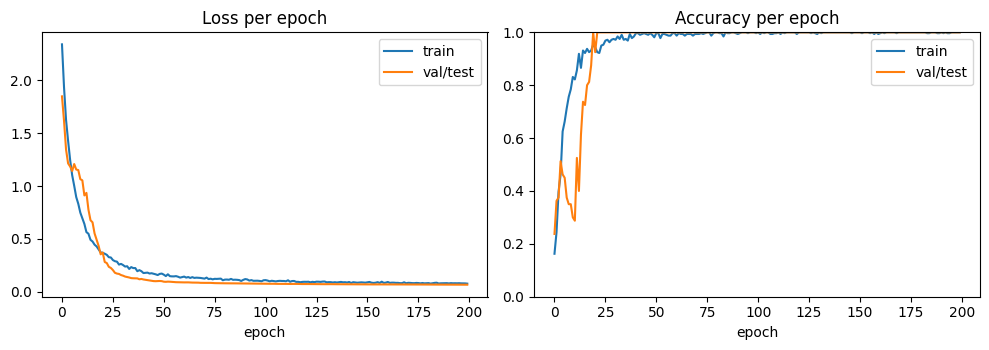

In [10]:
tr = np.array(results["train_acc"]); te = np.array(results["acc"])
gap = tr - te
print(f"Mean TRAIN accuracy : {tr.mean():.4f}")
print(f"Mean TEST  accuracy : {te.mean():.4f}")
print(f"Mean gap (train-test): {gap.mean():+.4f}  (per fold: {np.round(gap,3).tolist()})")
print(f"Test accuracy spread across folds (std): {te.std():.4f}")
if gap.mean() > 0.15:
    print("VERDICT: likely OVERFITTING - train much higher than test.")
elif gap.mean() > 0.07:
    print("VERDICT: mild overfitting - consider more dropout / L2 / data.")
else:
    print("VERDICT: no strong overfitting signal - train and test are close.")

# Learning curves (train vs validation) from the first fold
h = results["history"][0]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val/test")
ax[0].set_title("Loss per epoch"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(h["accuracy"], label="train"); ax[1].plot(h["val_accuracy"], label="val/test")
ax[1].set_title("Accuracy per epoch"); ax[1].set_xlabel("epoch"); ax[1].set_ylim(0, 1); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Per-gesture report + confusion matrix

Like the paper's Tables 4-5: which gestures the model confuses. Trains once on a
stratified split. (CCW/CW are full circles and Backspace/Autofill in your map, so watch
whether they get confused with each other.)

Per-class counts (train / test):
  Uw    train=  30  test=  10
  Ue    train=  30  test=  10
  Dn    train=  30  test=  10
  Ds    train=  30  test=  10
  Dw    train=  30  test=  10
  De    train=  30  test=  10
  DUD   train=  30  test=  10
  Un    train=  30  test=  10
  CCW   train=  30  test=  10
  CW    train=  30  test=  10
TOTAL: train=300  test=100  | epochs=200

                     precision    recall  f1-score   support

 Uw (Quadrant Left)       1.00      1.00      1.00        10
Ue (Quadrant Right)       1.00      1.00      1.00        10
     Dn (Letter Up)       1.00      1.00      1.00        10
   Ds (Letter Down)       1.00      1.00      1.00        10
   Dw (Letter Left)       1.00      1.00      1.00        10
  De (Letter Right)       1.00      1.00      1.00        10
       DUD (Select)       1.00      1.00      1.00        10
         Un (Space)       1.00      1.00      1.00        10
    CCW (Backspace)       1.00      1.00      1.00        10
      CW (Auto

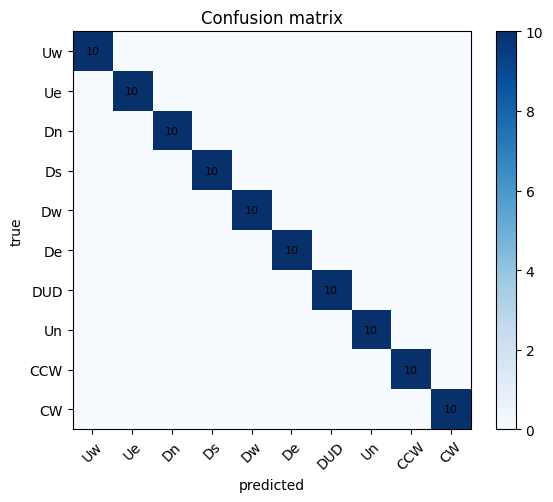

In [11]:
cfg = dict(CONFIG); cfg["max_epochs"] = 8 if QUICK_TEST else CONFIG["max_epochs"]   # CHANGED: full epochs by default
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)
# CHANGED: print per-class train/test sizes so you can see what is used
print("Per-class counts (train / test):")
for c in range(N_CLASSES):
    print(f"  {GESTURE_CLASSES[c]:5} train={int((ytr==c).sum()):4d}  test={int((yte==c).sum()):4d}")
print(f"TOTAL: train={len(ytr)}  test={len(yte)}  | epochs={cfg['max_epochs']}\n")
tf.keras.backend.clear_session()
m = build_model(X.shape[1:], N_CLASSES, cfg)
m.compile(optimizer=make_optimizer(cfg), loss="categorical_crossentropy", metrics=["accuracy"])
m.fit(Xtr, tf.keras.utils.to_categorical(ytr, N_CLASSES),
      validation_split=0.2, epochs=cfg["max_epochs"], batch_size=cfg["batch_size"],
      class_weight=class_weights(ytr, N_CLASSES, cfg),   # CHANGED: imbalance handling
      callbacks=[EarlyStopping(patience=cfg["es_patience"], restore_best_weights=True)], verbose=0)
pred = m.predict(Xte, verbose=0).argmax(1)

names = [f"{c} ({GESTURE_NAMES[c]})" for c in GESTURE_CLASSES]
print(classification_report(yte, pred, labels=range(N_CLASSES),
                            target_names=names, zero_division=0))

cm = confusion_matrix(yte, pred, labels=range(N_CLASSES))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(GESTURE_CLASSES, rotation=45)
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(GESTURE_CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if cm[i, j]: ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(im); plt.tight_layout(); plt.show()

## 11. Notes for your real run

1. **Set `DATASET = "smartwatch"`** and `SMARTWATCH_ROOT` to your CSV folder.
2. **Labels come from folder names** (`<CODE>_no_tremor/`), so your existing layout
   works as-is. Point `SMARTWATCH_ROOT` at a session folder
   (`gesture_data_june24_sofie_rightarm_sitting`), or at the parent to combine several
   sessions of the SAME 10-gesture set. The U/D/N orientation session is auto-skipped.
3. **You need many examples per gesture per person** — tens to hundreds. The paper's
   datasets had thousands of samples. With few recordings the model will overfit; the
   confusion matrix will tell you which gestures need more data.
4. **`target_len`** trims/stretches every recording to the same length. If your gestures
   vary a lot in duration, raise it; if they're short and fast, lower it.
5. **The `tremor` column is ignored** for gesture recognition. If you instead want to
   detect tremor, set the label to that column (binary) — happy to wire that variant up.
6. To reproduce paper-level accuracy you'll tune the `NOT IN PAPER` values (filters,
   GRU units, dropout, L2, batch size, target_len).